In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hate-speech-and-offensive-language-dataset/labeled_data.csv


In [2]:
#!pip install transformers
#!pip install datasets

In [3]:
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/kaggle/input/hate-speech-and-offensive-language-dataset/labeled_data.csv')
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [5]:
import seaborn as sns

<Axes: xlabel='class', ylabel='count'>

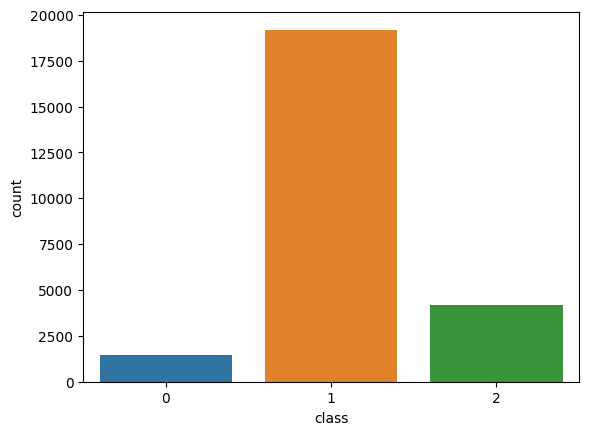

In [6]:
sns.countplot(x='class', data=df)

In [7]:
# Bert can handle stopwords and all so they will not be removed for this project 
df['tweet_cleaner'] = df['tweet'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)

In [8]:
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,tweet_cleaner
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,!!! RT : As a woman you shouldn't complain abo...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,!!!!! RT : boy dats cold...tyga dwn bad for cu...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,!!!!!!! RT Dawg!!!! RT : You ever fuck a bitch...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,!!!!!!!!! RT _G_Anderson: _based she look like...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,!!!!!!!!!!!!! RT : The shit you hear about me ...


## Loading Dataframe from Pandas

In [9]:
from datasets import Dataset

In [10]:
ds = Dataset.from_pandas(df)
ds

Dataset({
    features: ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet', 'tweet_cleaner'],
    num_rows: 24783
})

In [11]:
# Splitting this dataset into train test and valid sets 
train_test_valid = ds.train_test_split()

test_valid = train_test_valid['test'].train_test_split()
train_test_valid_dataset = DatasetDict({
    'train': train_test_valid['train'],
    'test': test_valid['test'],
    'valid': test_valid['train']
})

In [12]:
# Removing unwanted columns from the dataset
dataset = train_test_valid_dataset.remove_columns(['hate_speech', 'offensive_language', 'neither', 'Unnamed: 0', 'count'])
dataset

DatasetDict({
    train: Dataset({
        features: ['class', 'tweet', 'tweet_cleaner'],
        num_rows: 18587
    })
    test: Dataset({
        features: ['class', 'tweet', 'tweet_cleaner'],
        num_rows: 1549
    })
    valid: Dataset({
        features: ['class', 'tweet', 'tweet_cleaner'],
        num_rows: 4647
    })
})

## Tokenizer

In [13]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [14]:
# Testing the above tokenizer
text = "I am cute momo"
output = tokenizer(text)
output

{'input_ids': [101, 146, 1821, 10509, 4113, 1186, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

In [15]:
tokens = tokenizer.convert_ids_to_tokens(output['input_ids'])
tokens

['[CLS]', 'I', 'am', 'cute', 'mom', '##o', '[SEP]']

In [16]:
# Tokenizer Information
print(f"Vocab size is: {tokenizer.vocab_size}")
print(f"Vocab size is: {tokenizer.model_max_length}")
print(f"Vocab size is: {tokenizer.model_input_names}")

Vocab size is: 28996
Vocab size is: 512
Vocab size is: ['input_ids', 'token_type_ids', 'attention_mask']


In [17]:
def tokenize_function(train_dataset):
    return tokenizer(train_dataset['tweet_cleaner'], padding='max_length', truncation=True)

tokenized_dataset = dataset.map(tokenize_function, batched=True)

train_dataset = tokenized_dataset['train']
eval_dataset = tokenized_dataset['valid']
test_dataset = tokenized_dataset['test']

Map:   0%|          | 0/18587 [00:00<?, ? examples/s]

Map:   0%|          | 0/1549 [00:00<?, ? examples/s]

Map:   0%|          | 0/4647 [00:00<?, ? examples/s]

In [18]:
train_dataset

Dataset({
    features: ['class', 'tweet', 'tweet_cleaner', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 18587
})

In [19]:
train_data = train_dataset.remove_columns(['tweet', 'tweet_cleaner']).with_format('tensorflow')
tf_eval_data = eval_dataset.remove_columns(['tweet', 'tweet_cleaner']).with_format('tensorflow')
tf_test_data = test_dataset.remove_columns(['tweet', 'tweet_cleaner']).with_format('tensorflow')

In [20]:
train_features = {x: train_data[x] for x in tokenizer.model_input_names}
train_set_for_final_model = tf.data.Dataset.from_tensor_slices((train_features, train_data['class']))
train_set_for_final_model = train_set_for_final_model.shuffle(len(train_data)).batch(8)

eval_features = {x: tf_eval_data[x] for x in tokenizer.model_input_names}
val_set_for_final_model = tf.data.Dataset.from_tensor_slices((eval_features, tf_eval_data['class']))
val_set_for_final_model = val_set_for_final_model.batch(8)

test_features = {x: tf_test_data[x] for x in tokenizer.model_input_names}
test_set_for_final_model = tf.data.Dataset.from_tensor_slices((test_features, tf_test_data['class']))
test_set_for_final_model = test_set_for_final_model.batch(8)

In [21]:
tuned_model = TFAutoModelForSequenceClassification.from_pretrained("bert-base-cased", num_labels = 3)
tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
history = tuned_model.fit(train_set_for_final_model, validation_data=val_set_for_final_model, epochs=3)

Epoch 1/3
Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


I0000 00:00:1730796363.554002     103 service.cc:145] XLA service 0x7ef611a9bad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1730796363.554062     103 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1730796363.747335     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2324/2324 [==============================] - 1537s 622ms/step - loss: 0.3288 - sparse_categorical_accuracy: 0.8930 - val_loss: 0.2826 - val_sparse_categorical_accuracy: 0.9049
Epoch 2/3
2324/2324 [==============================] - 1431s 616ms/step - loss: 0.2704 - sparse_categorical_accuracy: 0.9070 - val_loss: 0.2966 - val_sparse_categorical_accuracy: 0.8864
Epoch 3/3
2324/2324 [==============================] - 1430s 615ms/step - loss: 0.2542 - sparse_categorical_accuracy: 0.9105 - val_loss: 0.2838 - val_sparse_categorical_accuracy: 0.8997


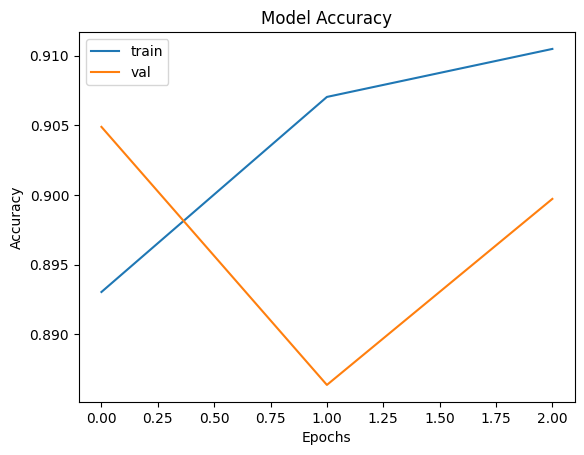

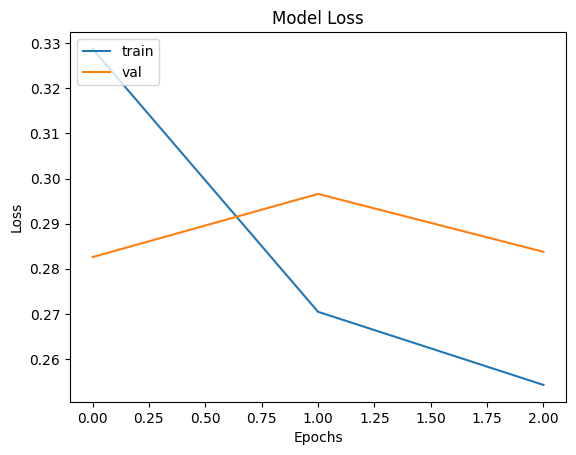

In [24]:
plt.plot(history.history['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Plotting training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [25]:
test_loss, test_acc = tuned_model.evaluate(test_set_for_final_model, verbose=2)
print('\nTest Accuracy: ', test_acc)

194/194 - 39s - loss: 0.2428 - sparse_categorical_accuracy: 0.9077 - 39s/epoch - 199ms/step

Test Accuracy:  0.9076823592185974


In [29]:
predict_score_and_class_dict= {0: 'Hate Speech',
 1: 'Offensive Language',
 2: 'Neither'}

preds = tuned_model(tokenizer(["He is useless, I dont know why he came to our neighbourhood", "That guy sucks", "He is such a retard"],return_tensors="tf",padding=True,truncation=True))['logits']

print(preds)

class_preds = np.argmax(preds, axis=1)

for pred in class_preds:
  print(predict_score_and_class_dict[pred])

tf.Tensor(
[[-1.0107691   0.12743059  0.3222187 ]
 [-1.392358    0.00415452  0.9083208 ]
 [-0.08535656  1.3097403  -2.0096545 ]], shape=(3, 3), dtype=float32)
Neither
Neither
Offensive Language


In [42]:
predict_score_and_class_dict = {0: 'Hate Speech',
 1: 'Offensive Language',
 2: 'Neither'}
preds = tuned_model(tokenizer(["you are sooooo cute"],return_tensors="tf",padding=True,truncation=True))['logits']
print(preds)
class_preds = np.argmax(preds, axis=1)

for pred in class_preds:
  print(predict_score_and_class_dict[pred])

tf.Tensor([[-1.0900619   0.07997242  0.4895328 ]], shape=(1, 3), dtype=float32)
Neither


In [32]:
output_dir = "/kaggle/working/fine_tuned_model" 
tuned_model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('/kaggle/working/fine_tuned_model/tokenizer_config.json',
 '/kaggle/working/fine_tuned_model/special_tokens_map.json',
 '/kaggle/working/fine_tuned_model/vocab.txt',
 '/kaggle/working/fine_tuned_model/added_tokens.json',
 '/kaggle/working/fine_tuned_model/tokenizer.json')